In [ ]:
import zipfile
import os

# Extract the zip file to a new folder
zip_file = "Kather_texture_2016_image_tiles_5000.zip"

if os.path.exists(zip_file):
    print(f"Extracting {zip_file}...")
    with zipfile.ZipFile(zip_file, 'r') as zip_ref:
        zip_ref.extractall("extracted_dataset")
    print("Extraction complete!")

    # Find the actual image folder (might be nested)
    for root, dirs, files in os.walk("extracted_dataset"):
        if "01_TUMOR" in dirs:
            data_path = root
            break
    else:
        # Try common path
        data_path = "extracted_dataset/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000"

    print(f"Data path: {data_path}")

    # Load dataset
    from torchvision.datasets import ImageFolder
    full_dataset = ImageFolder(data_path)
    class_names = full_dataset.classes
    print(f"Classes: {class_names}")
    print(f"Total images: {len(full_dataset)}")
else:
    print("Zip file not found!")

Extracting Kather_texture_2016_image_tiles_5000.zip...
Extraction complete!
Data path: extracted_dataset/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000
Classes: ['01_TUMOR', '02_STROMA', '03_COMPLEX', '04_LYMPHO', '05_DEBRIS', '06_MUCOSA', '07_ADIPOSE', '08_EMPTY']
Total images: 5000


In [ ]:
!pip install tqdm

In [ ]:
import os
from tqdm import tqdm
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import timm

In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import timm
from tqdm import tqdm

# =======================
# 🔒 Reproducibility
# =======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =======================
# ⚙️ Config
# =======================
DATA_DIR = "/content/extracted_dataset/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000"
IMG_SIZE = 300
BATCH_SIZE = 16
EPOCHS = 40
LR = 5e-5   # 🔥 reduced

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================
# 🎨 Transforms (IMPROVED)
# =======================
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.RandomAffine(degrees=15, translate=(0.1,0.1)),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])   # 🔥 fixed
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# =======================
# 📂 Dataset Split (FIXED COUNT)
# =======================
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

indices = list(range(len(full_dataset)))

train_idx, temp_idx = train_test_split(indices, train_size=500, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, train_size=63, test_size=62, random_state=42)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transforms), val_idx)
test_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transforms), test_idx)

# =======================
# 🚀 DataLoader (FIXED)
# =======================
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)

val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=True)

test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =======================
# 🧠 Model (B3 + DROPOUT)
# =======================
model = timm.create_model('efficientnet_b3', pretrained=True)

model.classifier = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(model.classifier.in_features, len(full_dataset.classes))
)

model = model.to(device)

# 👉 Freeze backbone
for param in model.parameters():
    param.requires_grad = False

for param in model.classifier.parameters():
    param.requires_grad = True

# =======================
# 🎯 Loss + Optimizer
# =======================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# =======================
# ⚡ AMP (UPDATED)
# =======================
scaler = torch.amp.GradScaler('cuda')

# =======================
# 🛑 Early Stopping
# =======================
best_val_loss = float('inf')
patience = 7
counter = 0

# =======================
# 🏋️ Training Loop
# =======================
for epoch in range(EPOCHS):

    # 👉 Unfreeze after 5 epochs
    if epoch == 5:
        for param in model.parameters():
            param.requires_grad = True

    model.train()
    train_loss = 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for images, labels in pbar:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    train_loss /= len(train_loader)   # 🔥 FIXED

    # ===================
    # 🔍 Validation
    # ===================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_loss /= len(val_loader)   # 🔥 FIXED
    val_acc = correct / total

    scheduler.step()

    print(f"\nTrain Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ===================
    # 💾 Save Best Model
    # ===================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# =======================
# 🧪 Testing + TTA
# =======================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

tta_transforms = [
    lambda x: x,
    lambda x: torch.flip(x, dims=[3]),
    lambda x: torch.flip(x, dims=[2]),
    lambda x: torch.rot90(x, 1, [2,3])   # 🔥 added
]

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs_sum = 0
        for t in tta_transforms:
            outputs_sum += model(t(images))

        outputs_avg = outputs_sum / len(tta_transforms)

        _, preds = torch.max(outputs_avg, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"🔥 Final Test Accuracy: {test_acc:.4f}")

Epoch 1: 100%|██████████| 32/32 [00:05<00:00,  5.68it/s, loss=2.2]



Train Loss: 2.0976
Val Loss: 2.0990, Val Acc: 0.0794


Epoch 2: 100%|██████████| 32/32 [00:04<00:00,  6.67it/s, loss=2.06]



Train Loss: 2.0456
Val Loss: 2.0661, Val Acc: 0.1905


Epoch 3: 100%|██████████| 32/32 [00:04<00:00,  7.16it/s, loss=2.13]


...


Train Loss: 0.6521
Val Loss: 0.8067, Val Acc: 0.8730


Epoch 37: 100%|██████████| 32/32 [00:06<00:00,  4.73it/s, loss=0.944]



Train Loss: 0.6474
Val Loss: 0.8061, Val Acc: 0.8730


Epoch 38: 100%|██████████| 32/32 [00:07<00:00,  4.40it/s, loss=1.47]



Train Loss: 0.6841
Val Loss: 0.8153, Val Acc: 0.8730
Early stopping triggered
🔥 Final Test Accuracy: 0.9355


In [ ]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
import timm

# =======================
# 🔒 Reproducibility
# =======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# =======================
# ⚙️ Config
# =======================
DATA_DIR = "/content/extracted_dataset/Kather_texture_2016_image_tiles_5000/Kather_texture_2016_image_tiles_5000"
IMG_SIZE = 300
BATCH_SIZE = 16
EPOCHS = 25
LR = 3e-4

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# =======================
# 🎨 Transforms
# =======================
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(0.2, 0.2, 0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# =======================
# 📂 Dataset Split
# =======================
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)

indices = list(range(len(full_dataset)))
train_idx, temp_idx = train_test_split(indices, test_size=0.2, random_state=42)
val_idx, test_idx = train_test_split(temp_idx, test_size=0.5, random_state=42)

train_dataset = Subset(full_dataset, train_idx)
val_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transforms), val_idx)
test_dataset = Subset(datasets.ImageFolder(DATA_DIR, transform=val_transforms), test_idx)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

# =======================
# 🧠 Model
# =======================
model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=len(full_dataset.classes))
model = model.to(device)

# =======================
# 🎯 Loss + Optimizer
# =======================
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=EPOCHS)

# =======================
# ⚡ Mixed Precision (OLD)
# =======================
scaler =torch.amp.GradScaler('cuda')

# =======================
# 🛑 Early Stopping
# =======================
best_val_loss = float('inf')
patience = 5
counter = 0

# =======================
# 🏋️ Training Loop
# =======================
for epoch in range(EPOCHS):
    model.train()
    train_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        train_loss += loss.item()

    # ===================
    # 🔍 Validation
    # ===================
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    val_acc = correct / total

    scheduler.step()

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss: {val_loss:.4f}, Val Acc: {val_acc:.4f}")

    # ===================
    # 💾 Save Best Model
    # ===================
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered")
        break

# =======================
# 🧪 Testing + TTA
# =======================
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

correct = 0
total = 0

tta_transforms = [
    lambda x: x,
    lambda x: torch.flip(x, dims=[3]),
    lambda x: torch.flip(x, dims=[2])
]

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs_sum = 0
        for t in tta_transforms:
            outputs = model(t(images))
            outputs_sum += outputs

        outputs_avg = outputs_sum / len(tta_transforms)

        _, preds = torch.max(outputs_avg, 1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = correct / total
print(f"🔥 Final Test Accuracy: {test_acc:.4f}")

Epoch 1
Train Loss: 252.8768
Val Loss: 21.9270, Val Acc: 0.9240
Epoch 2
Train Loss: 182.0095
Val Loss: 19.5801, Val Acc: 0.9720
Epoch 3
Train Loss: 166.5272
Val Loss: 19.1377, Val Acc: 0.9580
Epoch 4
Train Loss: 156.2732
Val Loss: 19.5636, Val Acc: 0.9520
Epoch 5
Train Loss: 152.2703
Val Loss: 18.8145, Val Acc: 0.9660
Epoch 6
Train Loss: 145.9268
Val Loss: 19.2636, Val Acc: 0.9520
Epoch 7
Train Loss: 137.8635
Val Loss: 18.3850, Val Acc: 0.9640
Epoch 8
Train Loss: 136.4467
Val Loss: 18.3225, Val Acc: 0.9600
Epoch 9
Train Loss: 135.6794
Val Loss: 18.3414, Val Acc: 0.9680
Epoch 10
Train Loss: 133.1437
Val Loss: 18.4120, Val Acc: 0.9640
Epoch 11
Train Loss: 129.9278
Val Loss: 20.1156, Val Acc: 0.9360
Epoch 12
Train Loss: 128.1973
Val Loss: 18.2548, Val Acc: 0.9620
Epoch 13
Train Loss: 124.8968
Val Loss: 17.3854, Val Acc: 0.9780
Epoch 14
Train Loss: 125.2065
Val Loss: 17.5240, Val Acc: 0.9700
Epoch 15
Train Loss: 123.4163
Val Loss: 18.9985, Val Acc: 0.9440
Epoch 16
Train Loss: 123.0092
Val 

In [ ]:
import torch
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load best model
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [ ]:
# Accuracy
accuracy = accuracy_score(all_labels, all_preds)

# Precision, Recall, F1 (weighted for multi-class)
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')

print("Model Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1 Score  : {f1:.4f}")

Model Performance:
Accuracy  : 0.9780
Precision : 0.9782
Recall    : 0.9780
F1 Score  : 0.9779


In [ ]:
class_names = test_loader.dataset.dataset.classes  # works for Subset

report = classification_report(all_labels, all_preds, target_names=class_names)

print("\n📊 Classification Report:\n")
print(report)


📊 Classification Report:

              precision    recall  f1-score   support

    01_TUMOR       0.97      0.96      0.97        74
   02_STROMA       0.94      0.98      0.96        61
  03_COMPLEX       0.96      0.91      0.94        57
   04_LYMPHO       0.96      0.98      0.97        55
   05_DEBRIS       1.00      1.00      1.00        67
   06_MUCOSA       1.00      1.00      1.00        62
  07_ADIPOSE       1.00      0.98      0.99        55
    08_EMPTY       0.99      1.00      0.99        69

    accuracy                           0.98       500
   macro avg       0.98      0.98      0.98       500
weighted avg       0.98      0.98      0.98       500



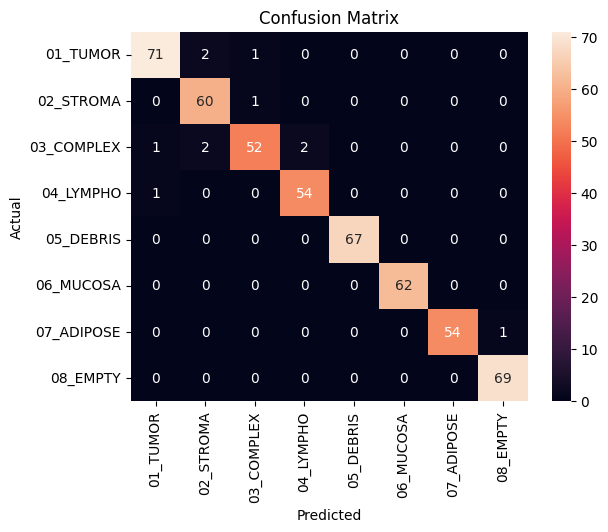

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=class_names,
            yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

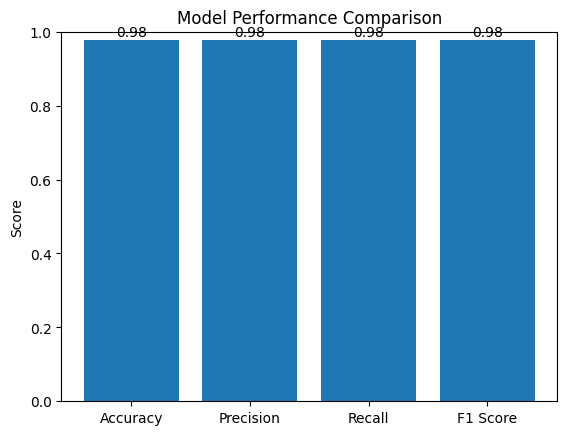

In [ ]:
import matplotlib.pyplot as plt

metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
values = [accuracy, precision, recall, f1]

plt.figure()
plt.bar(metrics, values)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()